# LangGraph RAG: Итерация 1 - Naive RAG

## Что мы изучаем в первой итерации

В этой итерации мы создадим **базовый RAG с интеллектуальной маршрутизацией запросов** для AI-консалтинговой компании. Система будет работать с документацией по услугам и портфолио компании Smirnoff AI и сможет:

- **Классифицировать запросы**: определять, нужен ли поиск в базе знаний или можно ответить напрямую
- **Извлекать релевантную информацию** из векторной базы данных
- **Генерировать ответы** на основе найденного контекста

### Ключевые концепции:

1. **StateGraph** - основа для управления состоянием в LangGraph
2. **Conditional routing** - умная маршрутизация между узлами графа
3. **Tool calling** - использование инструментов для поиска информации
4. **In-memory vector store** - векторное хранилище в памяти

### Архитектура решения

```mermaid
graph TD
    START([User Input]) --> QUERY[query_or_respond]
    QUERY --> |Нужен поиск| TOOLS[tools]
    QUERY --> |Прямой ответ| END([Response])
    TOOLS --> GENERATE[generate]
    GENERATE --> END
```

**Источники:** [LangGraph Tutorial](https://python.langchain.com/docs/tutorials/qa_chat_history/)


## Setup & Dependencies

Сначала установим необходимые пакеты и настроим компоненты системы.


In [2]:
%pip install --upgrade --quiet langgraph langchain-community langchain-openai beautifulsoup4 pypdf

# Load api keys vars from a .env file:
import os
import dotenv

# Загрузка переменных окружения
dotenv.load_dotenv('.env', override=True)

# Вывод всех ключей из окружения
env_keys = [
    "OPENAI_API_KEY",
    "TAVILY_API_KEY",
    "LANGSMITH_TRACING",
    "LANGSMITH_ENDPOINT",
    "LANGSMITH_API_KEY",
    "LANGSMITH_PROJECT",
    "LANGSMITH_DATASET",
    "MODEL",
    "EMBEDDING_MODEL",
]

print("Переменные окружения:")
for key in env_keys:
    value = os.getenv(key)
    if value:
        # Маскируем значение для безопасности (показываем только первые 10 символов)
        masked_value = value[:20] + "..." if len(value) > 20 else value
        print(f"  {key}: {masked_value}")
    else:
        print(f"  {key}: не установлена")
print()


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Переменные окружения:
  OPENAI_API_KEY: sk-or-v1-7bf6a22852a...
  TAVILY_API_KEY: tvly-dev-TaewHcVH68J...
  LANGSMITH_TRACING: true
  LANGSMITH_ENDPOINT: https://api.smith.la...
  LANGSMITH_API_KEY: lsv2_pt_87b63cdbe117...
  LANGSMITH_PROJECT: sberagents_live
  LANGSMITH_DATASET: 06-rag-qa-dataset
  MODEL: openai/gpt-oss-120b
  EMBEDDING_MODEL: openai/text-embeddin...



In [3]:
# Настройка основных компонентов

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

# 1. Языковая модель для генерации ответов
llm = ChatOpenAI(model=os.getenv("MODEL"))

# 2. Модель эмбеддингов для векторизации текста
embeddings = OpenAIEmbeddings(model=os.getenv("EMBEDDING_MODEL"))

# 3. Векторное хранилище в памяти
vector_store = InMemoryVectorStore(embeddings)


## Загрузка и обработка документов

Загружаем PDF документ с описанием услуг и портфолио AI-консалтинговой компании Smirnoff AI и разбиваем его на небольшие фрагменты (chunks) для более эффективного поиска.


In [4]:
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Загрузка PDF документов
docs = []
documents_path = "documents/"

for filename in ["smirnoff_ai.pdf"]:
    file_path = os.path.join(documents_path, filename)
    if os.path.exists(file_path):
        print(f"Загружаем: {filename}")
        loader = PyPDFLoader(file_path)
        docs.extend(loader.load())
    else:
        print(f"Файл не найден: {file_path}")

print(f"Загружено документов: {len(docs)}")

# Разбиение документов на небольшие фрагменты
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,    # Размер каждого фрагмента в символах
    chunk_overlap=200   # Перекрытие между фрагментами для сохранения контекста
)
all_splits = text_splitter.split_documents(docs)

print(f"Получено фрагментов: {len(all_splits)}")

# Индексация документов в векторное хранилище
_ = vector_store.add_documents(documents=all_splits)
print("Документы проиндексированы в векторное хранилище")


Загружаем: smirnoff_ai.pdf
Загружено документов: 14
Получено фрагментов: 24
Документы проиндексированы в векторное хранилище


## Проверка проиндексированных данных

Убедимся, что документы успешно проиндексированы и посмотрим на структуру данных.


In [5]:
# Проверяем проиндексированные чанки
print("📊 СТАТИСТИКА ИНДЕКСАЦИИ:")
print(f"Всего чанков в базе: {len(all_splits)}")
print()

# Группируем чанки по источникам
chunks_by_source = {}
for doc in all_splits:
    source = doc.metadata.get('source', 'unknown')
    filename = source.split('/')[-1] if '/' in source else source
    if filename not in chunks_by_source:
        chunks_by_source[filename] = 0
    chunks_by_source[filename] += 1

print("📁 ЧАНКИ ПО ФАЙЛАМ:")
for filename, count in chunks_by_source.items():
    print(f"  {filename}: {count} чанков")
print()

# Показываем примеры чанков
print("📄 ПРИМЕРЫ ЧАНКОВ (первые 3):")
for i, doc in enumerate(all_splits[:3]):
    print(f"\n--- ЧАНК {i+1} ---")
    print(f"Источник: {doc.metadata.get('source', 'unknown').split('/')[-1]}")
    print(f"Страница: {doc.metadata.get('page', 'N/A')}")
    print(f"Длина: {len(doc.page_content)} символов")
    print(f"Содержание: {doc.page_content[:200]}...")
    print("-" * 40)

# Тестируем поиск по векторной базе
print("\n🔍 ТЕСТ ПОИСКА:")
test_query = "SMIRNOFF_AI"
similar_docs = vector_store.similarity_search(test_query, k=2)
print(f"Запрос: '{test_query}'")
print(f"Найдено документов: {len(similar_docs)}")

for i, doc in enumerate(similar_docs):
    print(f"\nРезультат {i+1}:")
    print(f"Источник: {doc.metadata.get('source', 'unknown').split('/')[-1]}")  
    print(f"Фрагмент: {doc.page_content[:150]}...")
    
print("\n✅ Индексация завершена успешно!")


📊 СТАТИСТИКА ИНДЕКСАЦИИ:
Всего чанков в базе: 24

📁 ЧАНКИ ПО ФАЙЛАМ:
  smirnoff_ai.pdf: 24 чанков

📄 ПРИМЕРЫ ЧАНКОВ (первые 3):

--- ЧАНК 1 ---
Источник: smirnoff_ai.pdf
Страница: 0
Длина: 956 символов
Содержание: Профессиональная  разработка  ИИ-решений  для  бизнеса  
Профессиональная  разработка  и  внедрение  систем  искусственного  интеллекта,  ИИ-ассистентов,  ИИ-агентов,  ИИ-ботов  и  других  решений  на...
----------------------------------------

--- ЧАНК 2 ---
Источник: smirnoff_ai.pdf
Страница: 0
Длина: 966 символов
Содержание: ИИ-агенты  
Разработка  AI- агентов,  выполняющих  функции  сотрудников,  частично  и  полностью  замещая  их 
—  Корпоративный  HR- бот  для  сотрудников  РЖД  —  ИИ-аналитик  ситуационного  центра  ...
----------------------------------------

--- ЧАНК 3 ---
Источник: smirnoff_ai.pdf
Страница: 0
Длина: 841 символов
Содержание: Смирнов
 
Сергей
,
 
к.т.н.
 
https://t.me/smirno ﬀ _ai 
 
 
ЦИФРЫ
 
10+  ЛЕТ  В  РАЗРАБОТКЕ  ИИ  20+  ЛЕТ  В  РАЗРАБОТКЕ  П

## Создание StateGraph

StateGraph - это основа LangGraph, которая управляет состоянием и потоком выполнения. Мы используем MessagesState для работы с сообщениями.


In [6]:
from langgraph.graph import StateGraph
from typing import TypedDict, List, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# Определяем кастомное состояние агента
class AgentState(TypedDict):
    # messages - список всех сообщений в диалоге (пользователь + ИИ)
    # Annotated с add_messages означает, что новые сообщения будут добавляться к существующим
    messages: Annotated[List[BaseMessage], add_messages]

# Создаем граф состояний с нашим состоянием
graph_builder = StateGraph(AgentState)

# Альтернатива: можно короче использовать MessagesState из langgraph.graph
# from langgraph.graph import MessagesState
# graph_builder = StateGraph(MessagesState)

## Создание инструмента поиска

Инструмент retrieve будет искать релевантную информацию в нашей базе знаний.


In [7]:
from langchain_core.tools import tool

# Декоратор @tool превращает функцию в инструмент для LLM
@tool
def retrieve(query: str):
    """Поиск информации в базе знаний AI-консалтинговой компании Smirnoff AI по услугам, портфолио и экспертизе.
    
    Args:
        query: Поисковый запрос пользователя для поиска в документах компании
    """
    # Ищем 2 наиболее релевантных документа в векторной базе
    # k=2 ограничивает количество результатов для экономии токенов
    retrieved_docs = vector_store.similarity_search(query, k=2)
    
    # Формируем текстовое представление найденных документов
    # для передачи в LLM с информацией об источниках
    # Каждый документ содержит metadata (источник) и page_content (текст)
    serialized = "\n\n".join(
        (f"Источник: {doc.metadata}\n" f"Содержание: {doc.page_content}")
        for doc in retrieved_docs
    )
    
    return serialized
   
# Function Calling Details:
# - Имя функции: retrieve
# - Описание автоматически извлекается из docstring
# - Параметры автоматически определяются из аннотаций типов
# - LLM решает когда вызвать эту функцию на основе описания
# - При вызове llm.bind_tools([retrieve]) LLM получает схему функции
# - LLM может генерировать tool_calls в своем ответе

## Создание узлов графа

Наш граф состоит из трех узлов:
1. **query_or_respond** - решает, нужен ли поиск или можно ответить сразу
2. **tools** - выполняет поиск информации  
3. **generate** - генерирует финальный ответ


In [8]:
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode

# Узел 1: Генерация запроса или прямой ответ
def query_or_respond(state: AgentState):
    """Определяет, нужно ли использовать поиск или можно ответить напрямую."""
    
    # Системный промпт для первичной обработки запроса
    system_message = SystemMessage(
        content=(
            "Ты - помощник AI-консалтинговой компании Smirnoff AI. "
            "Если вопрос касается услуг, кейсов, экспертизы или портфолио компании - используй инструмент поиска. "
            "Если это общий вопрос или приветствие - отвечай напрямую кратко и направляй к использованию услуг."
        )
    )
    
    # Добавляем системный промпт к сообщениям
    messages_with_system = [system_message] + state["messages"]
    
    llm_with_tools = llm.bind_tools([retrieve])
    response = llm_with_tools.invoke(messages_with_system)

    # MessagesState добавляет сообщения к состоянию вместо перезаписи
    return {"messages": [response]}

# Узел 2: Выполнение поиска
tools = ToolNode([retrieve])

# Альтернативная реализация без ToolNode (для понимания):
# Нужна когда требуется кастомная обработка вызовов инструментов,
# например: логирование, валидация параметров, обработка ошибок,
# или когда инструменты имеют сложную логику взаимодействия
# def tools_node(state: MessagesState):
#     """Выполняет вызовы инструментов из последнего AI сообщения."""
#     # Получаем последнее сообщение от AI
#     last_message = state["messages"][-1]
    
#     # Выполняем все tool_calls из сообщения
#     tool_messages = []
#     for tool_call in last_message.tool_calls:
#         if tool_call["name"] == "retrieve":
#             # Вызываем функцию retrieve с аргументами
#             result = retrieve.invoke(tool_call["args"])
#             # Создаем ToolMessage с результатом
#             tool_message = ToolMessage(
#                 content=result,
#                 tool_call_id=tool_call["id"]
#             )
#             tool_messages.append(tool_message)
    
#     return {"messages": tool_messages}

# Узел 3: Генерация финального ответа
def generate(state: AgentState):
    """Генерирует ответ на основе найденной информации."""
    # Получаем последние сообщения от инструментов
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break
    tool_messages = recent_tool_messages[::-1]

    # Формируем промпт с найденной информацией
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    system_message_content = (
        "Ты - помощник AI-консалтинговой компании Smirnoff AI, специализирующийся на разработке "
        "AI-решений, ботов, агентов и консалтинге по внедрению ИИ. Используй следующую информацию из базы знаний "
        "для ответа на вопрос. Если не знаешь ответа, так и скажи. "
        "Отвечай максимум в трех предложениях и будь конкретен."
        "\n\n"
        f"{docs_content}"
    )
    
    # Собираем сообщения для модели (только пользовательские и ai)
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages

    # Генерируем ответ
    response = llm.invoke(prompt)
    return {"messages": [response]}


## Сборка и компиляция графа

Соединяем все узлы в единый граф с условной маршрутизацией.


In [9]:
from langgraph.graph import END
from langgraph.prebuilt import tools_condition

# Добавляем узлы к графу
graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)

# Определяем точку входа
graph_builder.set_entry_point("query_or_respond")

# Добавляем условные ребра (conditional routing)
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,  # Функция, которая решает куда идти дальше
    {END: END, "tools": "tools"},  # Маппинг: ключ = что возвращает функция, значение = куда переходить
)

# Кастомная реализация tools_condition:
# def tools_condition(state):
#     last_message = state["messages"][-1]
#     if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
#         return "tools"
#     return END

# Добавляем прямые ребра
graph_builder.add_edge("tools", "generate")  # После поиска -> генерация ответа
graph_builder.add_edge("generate", END)      # После генерации -> конец

# Компилируем граф (БЕЗ checkpointer - это будет в следующей итерации)
graph = graph_builder.compile()

print("Граф успешно собран!")


Граф успешно собран!


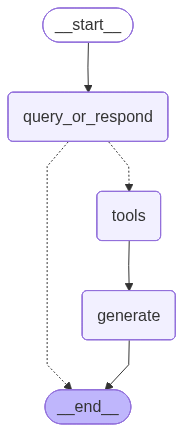

In [10]:
# Визуализация графа
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Не удалось отобразить граф: {e}")
    print("Структура графа:")
    print("start -> query_or_respond -> [tools -> generate] или [END]")


## Тестирование системы

Теперь протестируем нашу RAG систему различными типами запросов.


In [11]:
# Тест 1: Простое приветствие (должно ответить напрямую, БЕЗ поиска)
input_message = "Привет!"

print("=== ТЕСТ 1: Приветствие ===")
# Метод stream() возвращает промежуточные состояния на каждом шаге
# stream_mode="values" означает что получаем полное состояние на каждом шаге
# Цикл нужен, чтобы обработать все промежуточные результаты
for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    # step содержит состояние графа после выполнения очередного узла
    # step["messages"][-1] - это последнее сообщение в текущем состоянии
    step["messages"][-1].pretty_print()

# АЛЬТЕРНАТИВА: Если нужен только финальный результат без промежуточных шагов:
# result = graph.invoke({"messages": [{"role": "user", "content": input_message}]})
# result["messages"][-1].pretty_print()


=== ТЕСТ 1: Приветствие ===
================================ Human Message =================================

Привет!
================================== Ai Message ==================================

Привет! Рад приветствовать вас. Если вам интересна наша экспертиза, услуги или примеры проектов — дайте знать, я расскажу подробнее. Чем могу помочь?


In [12]:
# Тест 2: Вопрос по AI-услугам (должен использовать поиск)
input_message = "Какие AI-решения разрабатывает компания Smirnoff AI?"

print("\n=== ТЕСТ 2: Вопрос по AI-услугам ===")
for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()



=== ТЕСТ 2: Вопрос по AI-услугам ===
================================ Human Message =================================

Какие AI-решения разрабатывает компания Smirnoff AI?
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_vrJhig7zsSZqGXlHEpoTTXqv)
 Call ID: call_vrJhig7zsSZqGXlHEpoTTXqv
  Args:
    query: AI-решения разрабатывает Smirnoff AI услуги решения
================================= Tool Message =================================
Name: retrieve

Источник: {'producer': 'Skia/PDF m136 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'SMIRNOFF_AI. Профиль с портфолио', 'source': 'documents/smirnoff_ai.pdf', 'total_pages': 14, 'page': 0, 'page_label': '1'}
Содержание: Смирнов
 
Сергей
,
 
к.т.н.
 
https://t.me/smirno ﬀ _ai 
 
 
ЦИФРЫ
 
10+  ЛЕТ  В  РАЗРАБОТКЕ  ИИ  20+  ЛЕТ  В  РАЗРАБОТКЕ  ПО  10+  ПРОЕКТОВ  4   ПОБЕДЫ  в  ИИ-ХАКАТОНАХ  
СПЕЦИАЛИЗАЦИЯ
 
  GenAI,  LLM,  VLM,  RAG,  NLP,  CV,  OCR  
СТЕК

In [13]:
# Тест 3: Вопрос по AI-консалтингу
input_message = "Какие услуги по AI-консалтингу предоставляет Smirnoff AI?"

print("\n=== ТЕСТ 3: Вопрос по AI-консалтингу ===")
for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()



=== ТЕСТ 3: Вопрос по AI-консалтингу ===
================================ Human Message =================================

Какие услуги по AI-консалтингу предоставляет Smirnoff AI?
================================== Ai Message ==================================
Tool Calls:
  retrieve (functions.retrieve_6770)
 Call ID: functions.retrieve_6770
  Args:
    query: услуги AI-консалтинга Smirnoff AI
================================= Tool Message =================================
Name: retrieve

Источник: {'producer': 'Skia/PDF m136 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'SMIRNOFF_AI. Профиль с портфолио', 'source': 'documents/smirnoff_ai.pdf', 'total_pages': 14, 'page': 0, 'page_label': '1'}
Содержание: Смирнов
 
Сергей
,
 
к.т.н.
 
https://t.me/smirno ﬀ _ai 
 
 
ЦИФРЫ
 
10+  ЛЕТ  В  РАЗРАБОТКЕ  ИИ  20+  ЛЕТ  В  РАЗРАБОТКЕ  ПО  10+  ПРОЕКТОВ  4   ПОБЕДЫ  в  ИИ-ХАКАТОНАХ  
СПЕЦИАЛИЗАЦИЯ
 
  GenAI,  LLM,  VLM,  RAG,  NLP,  CV,  OCR  
СТЕК
 
ТЕХНОЛОГИЙ
 
  AI:

## Выводы по первой итерации

✅ **Что мы создали:**
- Базовый RAG с интеллектуальной маршрутизацией 
- Система автоматически решает: нужен поиск или нет
- Работает с PDF документами консалт компании
- Использует векторный поиск для релевантной информации

✅ **Ключевые компоненты:**
- **StateGraph** для управления потоком
- **Tool calling** для поиска информации  
- **Conditional routing** для умной маршрутизации
- **In-memory vector store** для быстрого поиска

## Что дальше?

В **следующей итерации** мы добавим:
- **Память диалога** с помощью Checkpointer
- Возможность вести **многооборотные беседы**
- **Контекст истории** для улучшения ответов

**Готовы к итерации 2 - Conversational RAG! 🚀**


# Итерация 2: Conversational RAG - Добавляем память диалога

## Что мы изучаем во второй итерации

В первой итерации мы создали базовый RAG, который умел отвечать на отдельные вопросы. Но что если пользователь хочет вести **диалог** и задавать уточняющие вопросы?

Например:
- Пользователь: "Расскажи про AmoCRM"
- Система: "AmoCRM предназначен для автоматизации..."  
- Пользователь: "А как там создавать контрагентов?" ← **Как система поймет, что "там" = AmoCRM?**

### Проблемы без памяти диалога:

❌ Система не помнит предыдущие вопросы  
❌ Контекстные вопросы ("А как это?", "А там как?") не работают  
❌ Каждый запрос обрабатывается изолированно  

### Что добавляем в итерации 2:

✅ **Checkpointer** - сохранение состояния диалога  
✅ **Thread Management** - изоляция разных пользователей  
✅ **Контекстные запросы** - система понимает "это", "там", "еще"  
✅ **Улучшенные запросы к ретриверу** - модель формулирует запросы с учетом истории  

### Ключевые концепции:

1. **MemorySaver** - встроенный checkpointer для сохранения состояния
2. **thread_id** - уникальный идентификатор для изоляции пользователей  
3. **MessagesState** - автоматическое накопление сообщений в состоянии
4. **Контекстное перефразирование** - LLM улучшает запросы на основе истории

### Архитектура остается той же:
```mermaid
graph TD
    START([User Input + History]) --> QUERY[query_or_respond]
    QUERY --> |Нужен поиск| TOOLS[tools]
    QUERY --> |Прямой ответ| END([Response])
    TOOLS --> GENERATE[generate] 
    GENERATE --> END
    END --> MEMORY[(Memory Store)]
```

**Источники:** [LangGraph Persistence](https://langchain-ai.github.io/langgraph/concepts/persistence/)


## Добавление памяти диалога с помощью Checkpointer

Для добавления памяти в наш граф нужно всего **одно изменение** - добавить checkpointer при компиляции.

**MemorySaver** - это встроенный checkpointer LangGraph, который сохраняет состояние в памяти. Для production можно использовать PostgreSQL или SQLite checkpointers.


In [14]:
# Добавляем память к нашему графу
from langgraph.checkpoint.memory import MemorySaver

# Создаем checkpointer для сохранения состояния диалога
memory = MemorySaver()

# Перекомпилируем граф с добавлением памяти
graph_with_memory = graph_builder.compile(checkpointer=memory)

# Для работы с памятью нужна конфигурация с thread_id
# Каждый thread_id = отдельная сессия пользователя
sample_config = {"configurable": {"thread_id": "user_anna"}}
print(f"Граф с памятью готов. Пример конфигурации: {sample_config}")


Граф с памятью готов. Пример конфигурации: {'configurable': {'thread_id': 'user_anna'}}


## Тестирование памяти и контекстных запросов

Теперь протестируем три ключевых возможности:

1. **Контекстные диалоги** - система понимает "там", "это", "еще"
2. **Умное перефразирование** - модель улучшает запросы на основе истории  
3. **Изоляция пользователей** - разные thread_id не пересекаются

Обратите внимание на **tool calls** - как модель формулирует запросы к ретриверу!


In [15]:
# ДИАЛОГ 1: Пользователь Анна спрашивает про AmoCRM
print("ПОЛЬЗОВАТЕЛЬ АННА - Thread ID: user_anna")

config_anna = {"configurable": {"thread_id": "user_anna"}} #telegram chat_id

# Первый вопрос - общий
for step in graph_with_memory.stream(
    {"messages": [{"role": "user", "content": "Расскажи про услуги Smirnoff AI"}]},
    stream_mode="values",
    config=config_anna,
):
    step["messages"][-1].pretty_print()


ПОЛЬЗОВАТЕЛЬ АННА - Thread ID: user_anna
================================ Human Message =================================

Расскажи про услуги Smirnoff AI
================================== Ai Message ==================================
Tool Calls:
  retrieve (chatcmpl-tool-cb710a3258d34d1082becde2503e3e98)
 Call ID: chatcmpl-tool-cb710a3258d34d1082becde2503e3e98
  Args:
    query: услуги Smirnoff AI
================================= Tool Message =================================
Name: retrieve

Источник: {'producer': 'Skia/PDF m136 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'SMIRNOFF_AI. Профиль с портфолио', 'source': 'documents/smirnoff_ai.pdf', 'total_pages': 14, 'page': 0, 'page_label': '1'}
Содержание: Смирнов
 
Сергей
,
 
к.т.н.
 
https://t.me/smirno ﬀ _ai 
 
 
ЦИФРЫ
 
10+  ЛЕТ  В  РАЗРАБОТКЕ  ИИ  20+  ЛЕТ  В  РАЗРАБОТКЕ  ПО  10+  ПРОЕКТОВ  4   ПОБЕДЫ  в  ИИ-ХАКАТОНАХ  
СПЕЦИАЛИЗАЦИЯ
 
  GenAI,  LLM,  VLM,  RAG,  NLP,  CV,  OCR  
СТЕК
 
ТЕХНОЛОГИЙ
 
 

In [16]:
# Второй вопрос - контекстный! 
for step in graph_with_memory.stream(
    {"messages": [{"role": "user", "content": "А в каких кейсах?"}]},
    stream_mode="values", 
    config=config_anna,
):
    step["messages"][-1].pretty_print()


================================ Human Message =================================

А в каких кейсах?
================================== Ai Message ==================================
Tool Calls:
  retrieve (fc_27176e0e-ae85-433e-8d88-3c63b0541f56)
 Call ID: fc_27176e0e-ae85-433e-8d88-3c63b0541f56
  Args:
    query: кейс Smirnoff AI
================================= Tool Message =================================
Name: retrieve

Источник: {'producer': 'Skia/PDF m136 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'SMIRNOFF_AI. Профиль с портфолио', 'source': 'documents/smirnoff_ai.pdf', 'total_pages': 14, 'page': 0, 'page_label': '1'}
Содержание: Смирнов
 
Сергей
,
 
к.т.н.
 
https://t.me/smirno ﬀ _ai 
 
 
ЦИФРЫ
 
10+  ЛЕТ  В  РАЗРАБОТКЕ  ИИ  20+  ЛЕТ  В  РАЗРАБОТКЕ  ПО  10+  ПРОЕКТОВ  4   ПОБЕДЫ  в  ИИ-ХАКАТОНАХ  
СПЕЦИАЛИЗАЦИЯ
 
  GenAI,  LLM,  VLM,  RAG,  NLP,  CV,  OCR  
СТЕК
 
ТЕХНОЛОГИЙ
 
  AI:  Python,  PyTorch,  Haystack,  LangChain,  LangGraph  и  др.  Data

In [17]:
# Третий вопрос - еще более контекстный!
for step in graph_with_memory.stream(
    {"messages": [{"role": "user", "content": "А что ещё?"}]},
    stream_mode="values",
    config=config_anna,
):
    step["messages"][-1].pretty_print()


================================ Human Message =================================

А что ещё?
================================== Ai Message ==================================
Tool Calls:
  retrieve (retrieve_ee23)
 Call ID: retrieve_ee23
  Args:
    query: Smirnoff AI кейсы
================================= Tool Message =================================
Name: retrieve

Источник: {'producer': 'Skia/PDF m136 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'SMIRNOFF_AI. Профиль с портфолио', 'source': 'documents/smirnoff_ai.pdf', 'total_pages': 14, 'page': 0, 'page_label': '1'}
Содержание: Смирнов
 
Сергей
,
 
к.т.н.
 
https://t.me/smirno ﬀ _ai 
 
 
ЦИФРЫ
 
10+  ЛЕТ  В  РАЗРАБОТКЕ  ИИ  20+  ЛЕТ  В  РАЗРАБОТКЕ  ПО  10+  ПРОЕКТОВ  4   ПОБЕДЫ  в  ИИ-ХАКАТОНАХ  
СПЕЦИАЛИЗАЦИЯ
 
  GenAI,  LLM,  VLM,  RAG,  NLP,  CV,  OCR  
СТЕК
 
ТЕХНОЛОГИЙ
 
  AI:  Python,  PyTorch,  Haystack,  LangChain,  LangGraph  и  др.  Data:  MongoDB,  PostgreSQL,  Dremio,  Kafka  и  др.  DevOps: 

In [18]:
# ДЕМОНСТРАЦИЯ ИЗОЛЯЦИИ: новый пользователь без контекста
print("ДЕМОНСТРАЦИЯ ИЗОЛЯЦИИ - ПОЛЬЗОВАТЕЛЬ ЧАРЛИ")

config_new_user = {"configurable": {"thread_id": "user_charlie"}}

for step in graph_with_memory.stream(
    {"messages": [{"role": "user", "content": "Что это?"}]},
    stream_mode="values",
    config=config_new_user,
):
    step["messages"][-1].pretty_print()

print("ВЫВОД: Thread'ы полностью изолированы!")


ДЕМОНСТРАЦИЯ ИЗОЛЯЦИИ - ПОЛЬЗОВАТЕЛЬ ЧАРЛИ
================================ Human Message =================================

Что это?
================================== Ai Message ==================================

Это — Smirnoff AI, AI‑консалтинговая компания. Мы помогаем клиентам разрабатывать и внедрять решения на базе искусственного интеллекта: от стратегии и аудита до разработки моделей и их интеграции в бизнес‑процессы. Если интересуют наши услуги, кейсы или портфолио — обращайтесь, будем рады помочь!
ВЫВОД: Thread'ы полностью изолированы!


## Важные особенности для продакшена

**ВАЖНЫЕ ОГРАНИЧЕНИЯ:**

• Контекст модели ограничен (~8000-32000 токенов)

• MemorySaver хранит ВСЮ историю в памяти

• Для production: PostgreSQL/SQLite checkpointers

• Рекомендация: ограничивать историю 10-20 сообщениями

**СТРАТЕГИИ УПРАВЛЕНИЯ ИСТОРИЕЙ:**

• Обрезка старых сообщений при достижении лимита

• Суммаризация длинной истории

• Очистка истории по команде пользователя


**ОЧИСТКА ИСТОРИИ:**

• Создать новый thread_id

• Использовать update_state() для сброса сообщений


## Выводы по второй итерации

✅ **Что мы добавили:**
- **Память диалога** с помощью MemorySaver checkpointer
- **Thread management** для изоляции пользователей
- **Контекстные запросы** - система понимает "это", "там", "еще"
- **Умное перефразирование** - модель улучшает запросы на основе истории

✅ **Ключевые достижения:**
- **MessagesState** автоматически накапливает историю
- **thread_id** обеспечивает изоляцию между пользователями
- **query_or_respond** генерирует лучшие запросы благодаря контексту
- **Простота добавления** - всего одна строка кода!

🔍 **Что мы наблюдали:**
- Модель успешно понимает контекстные вопросы
- Запросы к ретриверу становятся более точными
- Разные пользователи полностью изолированы
- История диалога сохраняется между запросами

